Converting a From-Scratch GPT Architecture to Llama 2

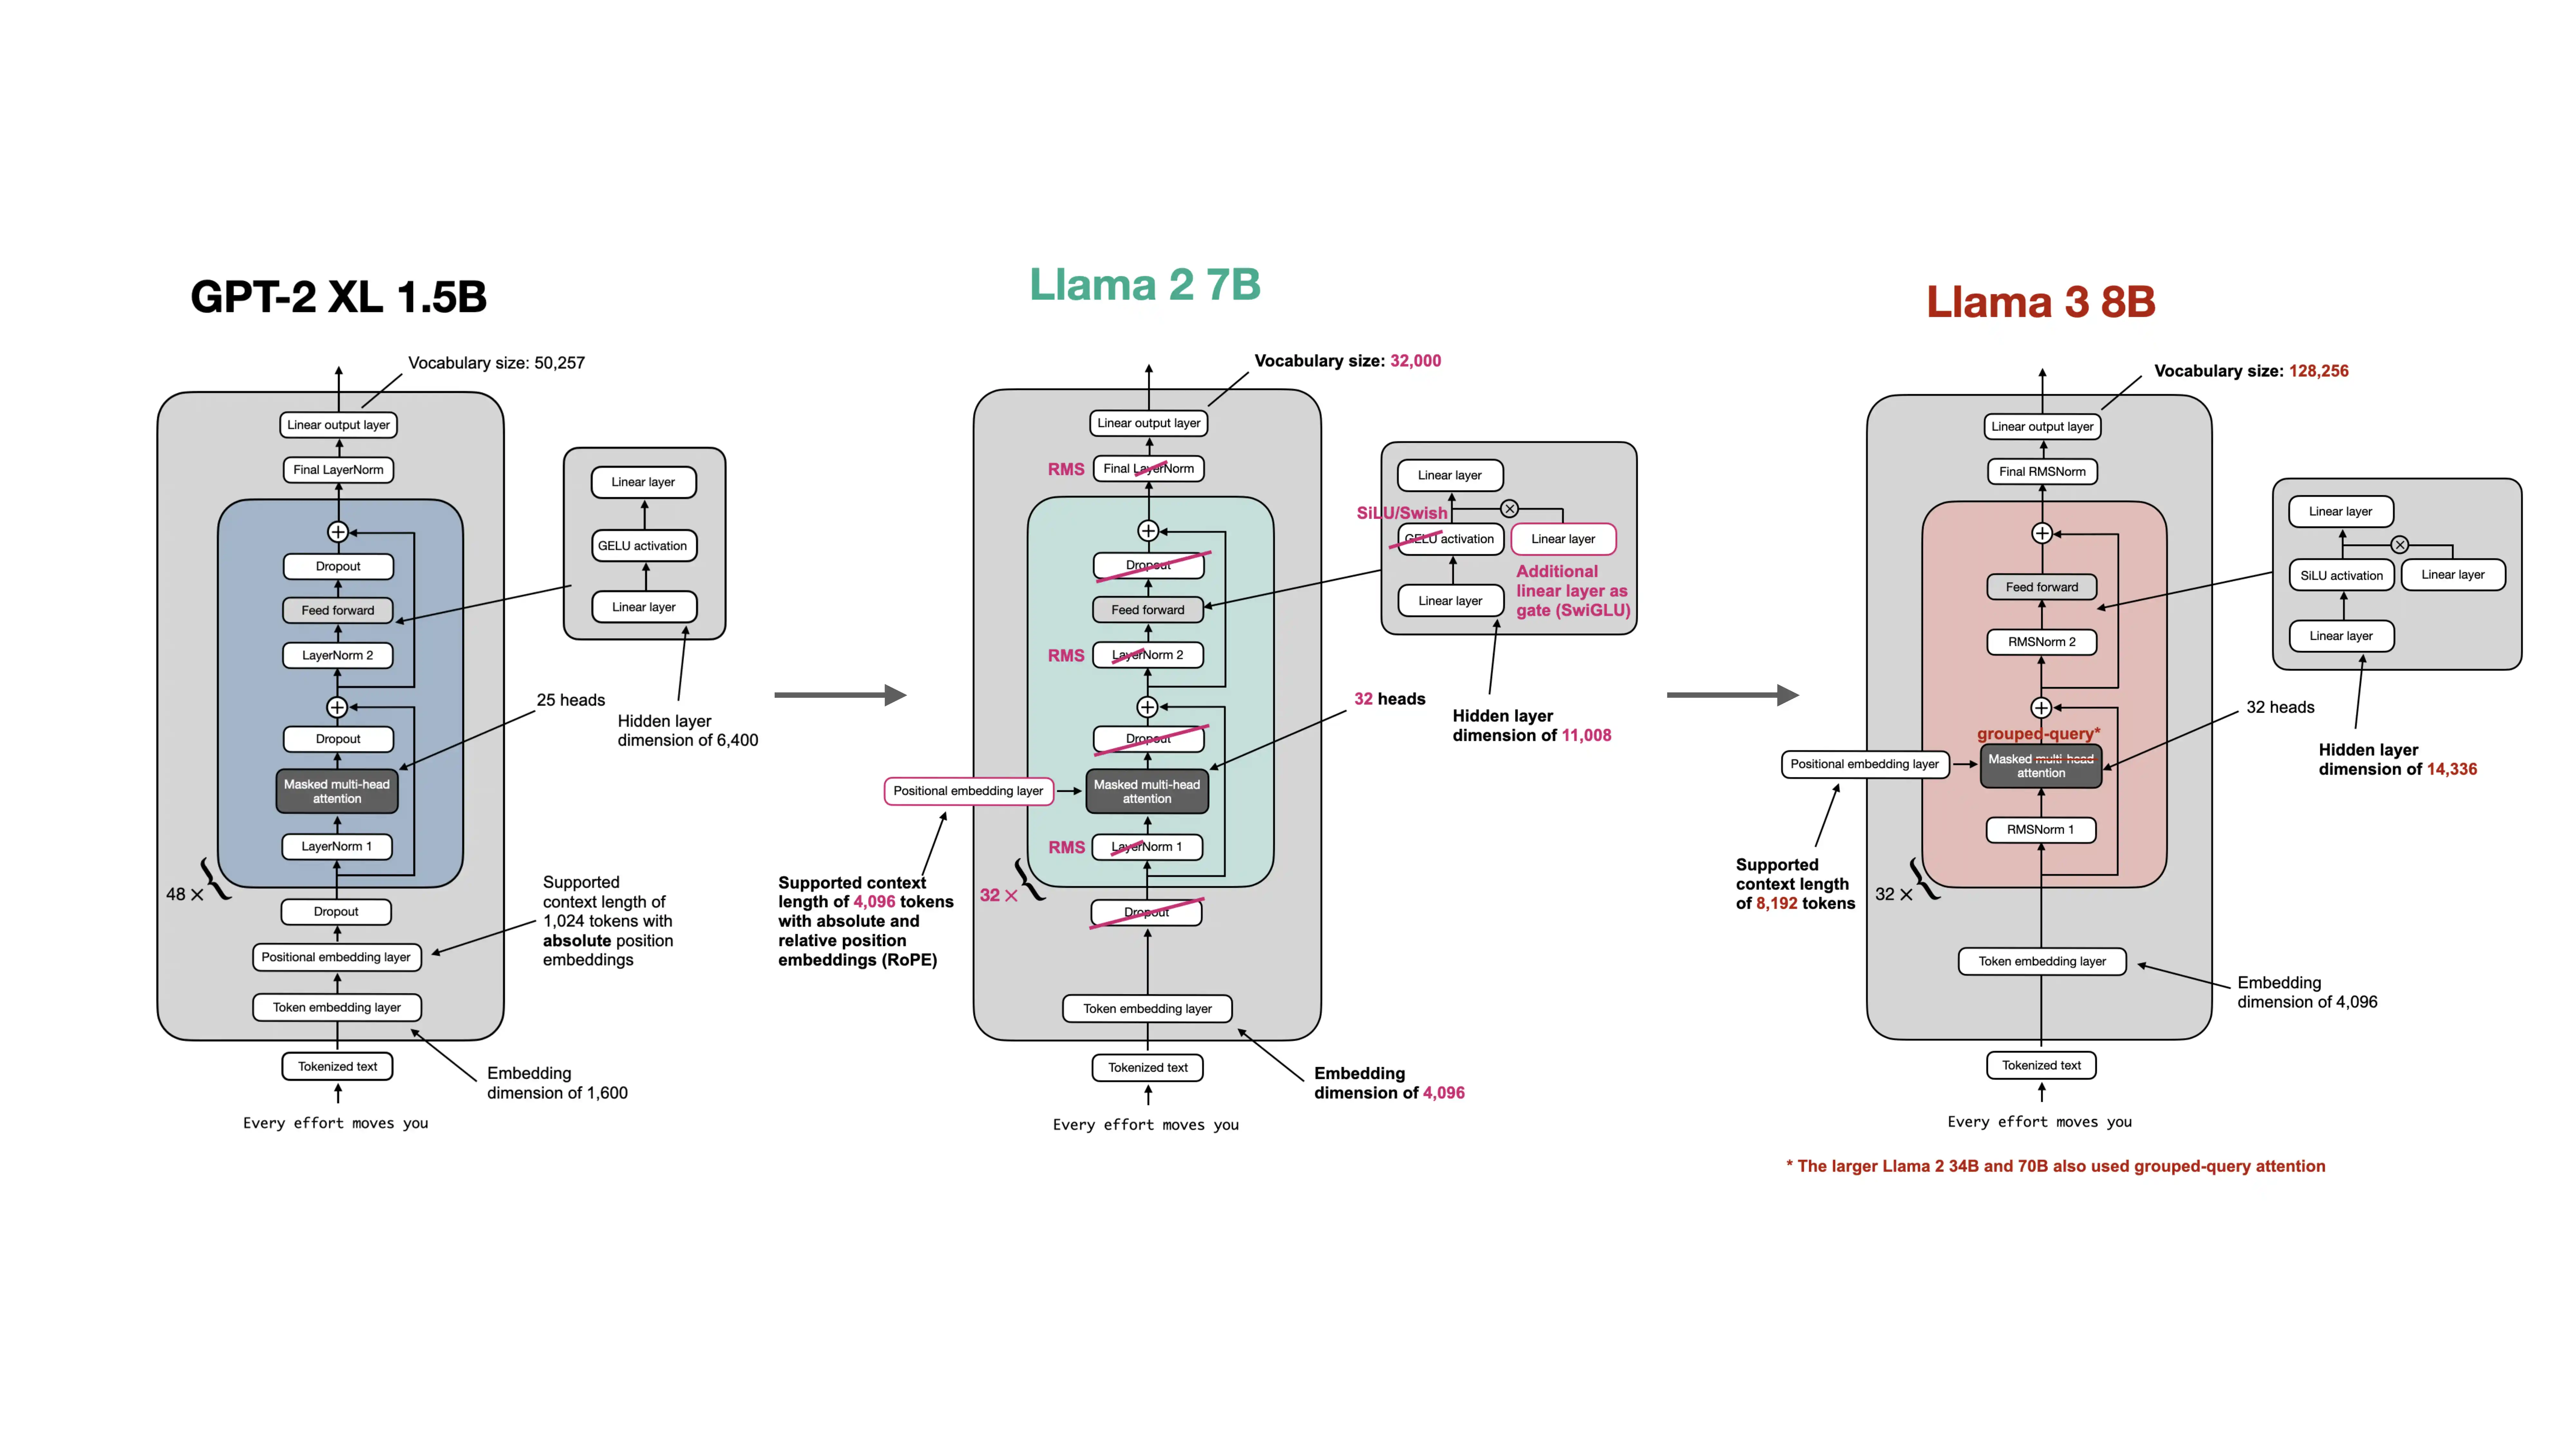

In [ ]:
from importlib.metadata import version

# 中文注释：检查本章所需第三方库的版本，便于复现实验环境
pkgs = [
    "huggingface_hub",  # to download pretrained weights
    "sentencepiece",    # to implement the tokenizer
    "torch",            # to implement the model
]
for p in pkgs:
    print(f"{p} version: {version(p)}")

1. Convert the GPT model implementation step by step
In this section, we go through the GPT model code from chapter 4 and modify it step by step to implement the Llama 2 architecture
Later, we load the original Llama 2 weights shared by Meta AI


1.1 Replace LayerNorm with RMSNorm layer
First, we replace LayerNorm by Root Mean Square Layer Normalization (RMSNorm)
LayerNorm normalizes inputs using mean and variance, while RMSNorm uses only the root mean square, which improves computational efficiency
The RMSNorm operation is as follows, where
 is the input
 is a trainable parameter (vector),

In [ ]:
import torch
import torch.nn as nn


#####################################
# Chapter 4
#####################################

# 中文注释：这是第 4 章 GPT 使用的 LayerNorm，Llama 2 用下面的 RMSNorm 将其替换
# class LayerNorm(nn.Module):
#     def __init__(self, emb_dim):
#         super().__init__()
#         self.eps = 1e-5
#         self.scale = nn.Parameter(torch.ones(emb_dim))
#         self.shift = nn.Parameter(torch.zeros(emb_dim))

#     def forward(self, x):
#         mean = x.mean(dim=-1, keepdim=True)
#         var = x.var(dim=-1, keepdim=True, unbiased=False)
#         norm_x = (x - mean) / torch.sqrt(var + self.eps)
#         return self.scale * norm_x + self.shift


# 中文注释：RMSNorm（均方根归一化），Llama 2 用它替代 LayerNorm。与 LayerNorm 的关键区别：
# 1) 不做“减均值”的 re-centering，只做基于均方根的 re-scaling；
# 2) 只有一个可学习参数 weight（对应 LayerNorm 的 scale），没有 shift/bias 参数；
# 3) 分母用 sqrt(mean(x^2) + eps)（均方根）而不是 sqrt(var(x) + eps)（标准差）。
# 计算更省、更稳定，是当前主流大模型（Llama 系列等）常用的归一化方式
class RMSNorm(nn.Module):
    def __init__(self, emb_dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.emb_dim = emb_dim
        # 中文注释：可学习缩放参数，形状 (emb_dim,)，初始化为全 1（等价于恒等缩放）
        self.weight = nn.Parameter(torch.ones(emb_dim)).float()

    def forward(self, x):
        # 中文注释：x 形状 (batch_size, seq_len, emb_dim)；对最后一维求平方后取均值 -> (batch_size, seq_len, 1)
        means = x.pow(2).mean(dim=-1, keepdim=True)
        # 中文注释：用 rsqrt（1/sqrt，比先 sqrt 再除更高效）做归一化，形状仍为 (batch_size, seq_len, emb_dim)
        x_normed = x * torch.rsqrt(means + self.eps)
        # 中文注释：乘以可学习 weight 后转换回输入原始 dtype（例如 bfloat16）
        return (x_normed * self.weight).to(dtype=x.dtype)

In [ ]:
torch.manual_seed(123)

# 中文注释：构造随机张量 (batch=2, seq_len=3, emb_dim=4)，用于验证自定义 RMSNorm 的正确性
example_batch = torch.randn(2, 3, 4)

rms_norm = RMSNorm(emb_dim=example_batch.shape[-1])
# 中文注释：与 PyTorch 官方 RMSNorm 实现做数值对比
rmsnorm_pytorch = torch.nn.RMSNorm(example_batch.shape[-1], eps=1e-5)

# 中文注释：断言两者输出数值一致，验证自定义实现无误
assert torch.allclose(rms_norm(example_batch), rmsnorm_pytorch(example_batch))

1.2 Replace GELU with SiLU activation

In [ ]:
#####################################
# Chapter 4
#####################################

# 中文注释：第 4 章 GPT 使用的 GELU 激活函数，Llama 2 用下面的 SiLU（也叫 Swish）将其替换
# class GELU(nn.Module):
#     def __init__(self):
#         super().__init__()

#     def forward(self, x):
#         return 0.5 * x * (1 + torch.tanh(
#             torch.sqrt(torch.tensor(2.0 / torch.pi)) *
#             (x + 0.044715 * torch.pow(x, 3))
#         ))


# 中文注释：SiLU(x) = x * sigmoid(x)，计算比 GELU 简单（无需 tanh 近似），用作 SwiGLU 的门控激活
class SiLU(nn.Module):
    def __init__(self):
        super(SiLU, self).__init__()

    def forward(self, x):
        return x * torch.sigmoid(x)

In [ ]:
silu = SiLU()

# 中文注释：验证自定义 SiLU 与 PyTorch 官方 F.silu 数值一致
assert torch.allclose(silu(example_batch), torch.nn.functional.silu(example_batch))

1.3 Update the FeedForward module

In [ ]:
# 中文注释：SwiGLU 前馈网络，替换 GPT 中“两层线性 + GELU”的 MLP
# 结构：fc1、fc2 都是 emb_dim -> hidden_dim（分别是门控分支与值分支），fc3 是 hidden_dim -> emb_dim（投影回原维度）
# 前向：SwiGLU(x) = fc3( SiLU(fc1(x)) * fc2(x) )，用门控机制替代单一激活函数，表达能力更强
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.fc1 = nn.Linear(cfg["emb_dim"], cfg["hidden_dim"], dtype=cfg["dtype"], bias=False)
        self.fc2 = nn.Linear(cfg["emb_dim"], cfg["hidden_dim"], dtype=cfg["dtype"], bias=False)
        self.fc3 = nn.Linear(cfg["hidden_dim"], cfg["emb_dim"], dtype=cfg["dtype"], bias=False)
        self.silu = SiLU()

    def forward(self, x):
        # 中文注释：x 形状 (batch_size, seq_len, emb_dim)
        # x_fc1、x_fc2 形状均为 (batch_size, seq_len, hidden_dim)
        x_fc1 = self.fc1(x)
        x_fc2 = self.fc2(x)
        # 中文注释：SiLU(门控) * 值，逐元素相乘，形状仍为 (batch_size, seq_len, hidden_dim)
        x = self.silu(x_fc1) * x_fc2
        # 中文注释：投影回嵌入维度 -> (batch_size, seq_len, emb_dim)
        return self.fc3(x)

1.4 Implement RoPE

In [ ]:
# 中文注释：RoPE（旋转位置编码，Rotary Position Embedding）参数预计算。
# Llama 2 不再使用可学习的绝对位置嵌入（GPT 中的 pos_emb），而是在注意力计算里对 Q、K
# 按位置施加“旋转”，从而隐式编码相对位置信息
def precompute_rope_params(head_dim, theta_base=10_000, context_length=4096):
    assert head_dim % 2 == 0, "Embedding dimension must be even"

    # Compute the inverse frequencies
    # 中文注释：inv_freq 形状为 (head_dim // 2,)，每一对维度对应一个旋转频率，频率随维度下标指数衰减
    inv_freq = 1.0 / (theta_base ** (torch.arange(0, head_dim, 2)[: (head_dim // 2)].float() / head_dim))

    # Generate position indices
    # 中文注释：positions 形状为 (context_length,)，即 0, 1, ..., context_length-1
    positions = torch.arange(context_length)

    # Compute the angles
    # 中文注释：外积，得到每个位置、每个频率对应的旋转角度，形状 (context_length, head_dim // 2)
    angles = positions.unsqueeze(1) * inv_freq.unsqueeze(0)  # Shape: (context_length, head_dim // 2)

    # Expand angles to match the head_dim
    # 中文注释：复制拼接，把角度扩展到完整的 head_dim，供下面对前后两半做旋转
    angles = torch.cat([angles, angles], dim=1)  # Shape: (context_length, head_dim)

    # Precompute sine and cosine
    # 中文注释：预先算好 cos/sin 表，形状均为 (context_length, head_dim)，之后按序列长度切片查表即可
    cos = torch.cos(angles)
    sin = torch.sin(angles)

    return cos, sin

# 中文注释：对 Q 或 K 张量应用旋转位置编码
def compute_rope(x, cos, sin):
    # x: (batch_size, num_heads, seq_len, head_dim)
    # 中文注释：x 是多头注意力中的 Q 或 K，形状为 (batch_size, num_heads, seq_len, head_dim)
    batch_size, num_heads, seq_len, head_dim = x.shape
    assert head_dim % 2 == 0, "Head dimension must be even"

    # Split x into first half and second half
    # 中文注释：把 head_dim 一分为二，x1、x2 形状均为 (batch_size, num_heads, seq_len, head_dim // 2)
    x1 = x[..., : head_dim // 2]  # First half
    x2 = x[..., head_dim // 2 :]  # Second half

    # Adjust sin and cos shapes
    # 中文注释：按当前序列长度截取并扩展 batch/head 维以便广播，cos, sin 最终形状均为 (1, 1, seq_len, head_dim)
    cos = cos[:seq_len, :].unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, seq_len, head_dim)
    sin = sin[:seq_len, :].unsqueeze(0).unsqueeze(0)

    # Apply the rotary transformation
    # 中文注释：rotated = [-x2, x1]，相当于把每一对 (x1_i, x2_i) 视为二维向量，乘以旋转矩阵 [[cos, -sin], [sin, cos]]
    # x_rotated 形状与输入 x 相同：(batch_size, num_heads, seq_len, head_dim)
    rotated = torch.cat((-x2, x1), dim=-1)
    x_rotated = (x * cos) + (rotated * sin)

    return x_rotated.to(dtype=x.dtype)

In [ ]:
# Settings
batch_size = 2
context_len = 5
num_heads = 4
head_dim = 16

# Instantiate RoPE parameters
# 中文注释：预计算的 cos/sin 表，形状均为 (context_len, head_dim)
cos, sin = precompute_rope_params(head_dim=head_dim, context_length=context_len)

# Dummy query and key tensors
torch.manual_seed(123)
# 中文注释：随机构造 Q、K 演示，形状均为 (batch_size, num_heads, context_len, head_dim)
queries = torch.randn(batch_size, num_heads, context_len, head_dim)
keys = torch.randn(batch_size, num_heads, context_len, head_dim)

# Apply rotary position embeddings
# 中文注释：对 Q、K 分别施加旋转位置编码，输出形状不变，只是每个位置的向量被“旋转”了对应角度
queries_rot = compute_rope(queries, cos, sin)
keys_rot = compute_rope(keys, cos, sin)

1.5 Add RoPE to MultiHeadAttention module

In [ ]:
# 中文注释：在第 3 章多头自注意力基础上做两处关键改动：
# 1) 所有线性层去掉 bias，并支持传入 dtype（如 bfloat16）；
# 2) 在计算注意力分数前，对 Q、K 施加 RoPE 旋转位置编码，取代 GPT 中的绝对位置嵌入
#####################################
# Chapter 3
#####################################
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, num_heads, dtype=None):  # ,dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by n_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # Reduce the projection dim to match desired output dim

        ################################### NEW ###################################
        # Set bias=False and dtype=dtype for all linear layers below
        ###########################################################################
        self.W_query = nn.Linear(d_in, d_out, bias=False, dtype=dtype)
        self.W_key = nn.Linear(d_in, d_out, bias=False, dtype=dtype)
        self.W_value = nn.Linear(d_in, d_out, bias=False, dtype=dtype)
        self.out_proj = nn.Linear(d_out, d_out, bias=False, dtype=dtype)  # Linear layer to combine head outputs
        # self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

        ################################### NEW ###################################
        # 中文注释：在注意力模块内部预计算并缓存 RoPE 的 cos/sin 表（非可训练参数，用 buffer 保存）
        # 形状均为 (context_length, head_dim)，注意这里用的是 head_dim（每个头的维度），而不是 d_out
        cos, sin = precompute_rope_params(head_dim=self.head_dim, context_length=context_length)
        self.register_buffer("cos", cos)
        self.register_buffer("sin", sin)
        ###########################################################################


    def forward(self, x):

        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)  # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        ################################### NEW ###################################
        # 中文注释：对 Q、K 施加 RoPE（values 不做旋转），形状保持 (b, num_heads, num_tokens, head_dim)
        keys = compute_rope(keys, self.cos, self.sin)
        queries = compute_rope(queries, self.cos, self.sin)
        ###########################################################################

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        # 中文注释：Llama 2 原始实现不使用注意力 dropout，这里已去掉，保留注释仅作对比
        # attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.reshape(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)  # optional projection

        return context_vec

In [ ]:
# Settings
batch_size = 1
context_len = 100
max_context_len = 4096
embed_dim = 128
num_heads = 4


# 中文注释：用随机输入测试新版 MultiHeadAttention（已集成 RoPE）能否正常前向传播
example_batch = torch.randn((batch_size, context_len, embed_dim))

mha = MultiHeadAttention(
    d_in=embed_dim,
    d_out=embed_dim,
    context_length=max_context_len,
    num_heads=num_heads
)

mha(example_batch)

del mha  # delete to free up memory

1.6 Update the TransformerBlock module
At this stage, most of the hard work is already done; we can now update the TransformerBlock to use the code we implemented above
This means we
replace LayerNorm with RMSNorm
remove dropout
remove the qkv_bias setting
add the dtype setting

In [ ]:
# 中文注释：Transformer 块，相对 GPT 版本的改动：
# 1) norm1/norm2 由 LayerNorm 换成 RMSNorm；2) 去掉残差分支上的 dropout（Llama 2 不用 dropout）；
# 3) 内部的 MultiHeadAttention 已集成 RoPE，FeedForward 已是 SwiGLU 结构
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dtype=cfg["dtype"]  # NEW
            # dropout=cfg["drop_rate"],
            # qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)

        ################################### NEW ###################################
        # self.norm1 = LayerNorm(cfg["emb_dim"])
        # self.norm2 = LayerNorm(cfg["emb_dim"])
        # 中文注释：用 RMSNorm 替换 LayerNorm
        self.norm1 = RMSNorm(cfg["emb_dim"])
        self.norm2 = RMSNorm(cfg["emb_dim"])
        ###########################################################################

        # 中文注释：Llama 2 不使用 dropout，因此不再实例化 drop_shortcut
        # self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    # 中文注释：forward 中 x 的形状全程保持 (batch_size, num_tokens, emb_dim)
    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)   # Shape [batch_size, num_tokens, emb_size]
        # x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed-forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        # x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

1.7 Update the model class
As you may recall from chapter 5, the TransformerBlock is a repeated block within the main model
Our Llama model is almost complete; we just have to update the model code surrounding the TransformerBlock
This means we
remove absolute positional embeddings since we have RoPE embeddings now
replace LayerNorm with RMSNorm
remove dropout
add the dtype setting

In [ ]:
# 中文注释：Llama2Model 相对 GPTModel 的主要改动：
# 1) 去掉 pos_emb（绝对位置嵌入）——位置信息改由每层内部的 RoPE 提供；
# 2) 去掉 drop_emb（Llama 2 不使用 dropout）；3) final_norm 由 LayerNorm 换成 RMSNorm
# class GPTModel(nn.Module):
class Llama2Model(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"], dtype=cfg["dtype"])
        # self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        # self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        ################################### NEW ###################################
        # self.final_norm = LayerNorm(cfg["emb_dim"])
        self.final_norm = RMSNorm(cfg["emb_dim"])
        ###########################################################################
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False, dtype=cfg["dtype"])

    def forward(self, in_idx):
        # batch_size, seq_len = in_idx.shape
        # 中文注释：in_idx 形状 (batch_size, seq_len)，是 token id
        tok_embeds = self.tok_emb(in_idx)
        # pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        # 中文注释：不再像 GPT 那样把 token 嵌入和位置嵌入相加，位置信息完全交给各层内部的 RoPE 处理
        x = tok_embeds  # + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        # x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        # 中文注释：logits 形状 (batch_size, seq_len, vocab_size)
        logits = self.out_head(x)
        return logits

2. Initialize model

In [ ]:
# 中文注释：GPT-2 124M 的配置，仅作为对比基准（后面用于跟 Llama 2 7B 做参数量/结构对比）
GPT_CONFIG_124M = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "emb_dim": 768,          # Embedding dimension
    "n_heads": 12,           # Number of attention heads
    "n_layers": 12,          # Number of layers
    "drop_rate": 0.1,        # Dropout rate
    "qkv_bias": False        # Query-Key-Value bias
}

In [ ]:
# 中文注释：GPT-2 1558M（1.5B）的配置，同样只用于对比
GPT_CONFIG_1558M = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "emb_dim": 1600,         # Embedding dimension
    "n_heads": 25,           # Number of attention heads
    "n_layers": 48,          # Number of layers
    "drop_rate": 0.1,        # Dropout rate
    "qkv_bias": False        # Query-Key-Value bias
}

In [ ]:
# 中文注释：Llama 2 7B 的配置，相对 GPT 配置的变化：
# - 不再需要 drop_rate / qkv_bias（Llama 2 不用 dropout，也不给 QKV 加 bias）
# - 新增 hidden_dim：SwiGLU 前馈网络中间层的维度（远大于 emb_dim，用于扩展表达能力）
# - 新增 dtype：直接以 bfloat16 存储权重，大幅降低显存占用
LLAMA2_CONFIG_7B = {
    "vocab_size": 32000,     # Vocabulary size
    "context_length": 4096,  # Context length
    "emb_dim": 4096,         # Embedding dimension
    "n_heads": 32,           # Number of attention heads
    "n_layers": 32,          # Number of layers
    "hidden_dim": 11008,     # NEW: Size of the intermediate dimension in FeedForward
    "dtype": torch.bfloat16  # NEW: Lower-precision dtype to reduce memory usage
}

In [ ]:
# 中文注释：按 Llama 2 7B 配置实例化模型（此时权重仍是随机初始化，后面会加载预训练权重）
model = Llama2Model(LLAMA2_CONFIG_7B)

In [ ]:
# 中文注释：统计模型总参数量，核对是否与 Llama 2 7B 的官方参数量级（约 70 亿）一致
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

In [ ]:
# 中文注释：粗略估算模型在给定 dtype（如 float32 / bfloat16）下大致占用的显存/内存，
# 把“参数 + 梯度 + 缓冲区”都按同一种 dtype 计算大小，仅用于直观比较不同精度的资源占用，
# 不代表训练/推理时的真实峰值显存
def calc_model_memory_size(model, input_dtype=torch.float32):
    total_params = 0
    total_grads = 0
    for param in model.parameters():
        # Calculate total number of elements per parameter
        param_size = param.numel()
        total_params += param_size
        # Check if gradients are stored for this parameter
        if param.requires_grad:
            total_grads += param_size

    # Calculate buffer size (non-parameters that require memory)
    # 中文注释：buffer 包括 mask，以及每个注意力层缓存的 RoPE cos/sin 表
    total_buffers = sum(buf.numel() for buf in model.buffers())

    # Size in bytes = (Number of elements) * (Size of each element in bytes)
    # We assume parameters and gradients are stored in the same type as input dtype
    element_size = torch.tensor(0, dtype=input_dtype).element_size()
    total_memory_bytes = (total_params + total_grads + total_buffers) * element_size

    # Convert bytes to gigabytes
    total_memory_gb = total_memory_bytes / (1024**3)

    return total_memory_gb

print(f"float32 (PyTorch default): {calc_model_memory_size(model, input_dtype=torch.float32):.2f} GB")
print(f"bfloat16: {calc_model_memory_size(model, input_dtype=torch.bfloat16):.2f} GB")

In [ ]:
# 中文注释：优先使用 GPU（CUDA），其次 Apple Silicon 的 MPS，都不可用时退回 CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

model.to(device);

3. Load tokenizer

In [ ]:
# 中文注释：从本地 config.json 读取 Hugging Face 访问令牌并登录，用于下载需要授权的 Llama 2 权重
from huggingface_hub import login
import json

with open("config.json", "r") as config_file:
    config = json.load(config_file)
    access_token = config["HF_ACCESS_TOKEN"]

login(token=access_token)


In [ ]:
# 中文注释：从 Hugging Face Hub 下载 Llama 2 7B 使用的 SentencePiece 分词器模型文件
from huggingface_hub import hf_hub_download

tokenizer_file = hf_hub_download(
    repo_id="meta-llama/Llama-2-7b",
    filename="tokenizer.model",
    local_dir="Llama-2-7b"
)

In [ ]:
import sentencepiece as spm


# 中文注释：对 SentencePiece 分词器的简单封装，提供与前面章节 GPT tokenizer 类似的 encode/decode 接口
class LlamaTokenizer:
    def __init__(self, tokenizer_file):
        sp = spm.SentencePieceProcessor()
        sp.load(tokenizer_file)
        self.tokenizer = sp

    def encode(self, text):
        return self.tokenizer.encode(text, out_type=int)

    def decode(self, ids):
        return self.tokenizer.decode(ids)


tokenizer = LlamaTokenizer(tokenizer_file)

In [ ]:
from previous_chapters import generate, text_to_token_ids, token_ids_to_text
# If the `previous_chapters.py` file is not available locally,
# you can import it from the `llms-from-scratch` PyPI package.
# For details, see: https://github.com/rasbt/LLMs-from-scratch/tree/main/pkg
# E.g.,
# from llms_from_scratch.ch05 import generate, text_to_token_ids, token_ids_to_text
# 中文注释：旁注——PyPI 包的正确导入路径是 llms_from_scratch（对应仓库名 LLMs-from-scratch，
# 而不是本地文件夹名 Build_an_LLM_from_Scratch）。上面这行注释本身写法是对的，
# 这里仅提醒不要误写成 `from Build_an_LLM_from_Scratch...`



# 中文注释：此时模型权重仍是随机初始化（尚未加载预训练权重），这里只是验证 generate/tokenizer 流程能跑通
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves", tokenizer).to(device),
    max_new_tokens=30,
    context_size=LLAMA2_CONFIG_7B["context_length"],
    top_k=1,
    temperature=0.
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

4. Load pretrained weights

In [ ]:
# 中文注释：下载 Llama 2 7B 基座模型的预训练权重文件（consolidated.00.pth，Meta 官方 checkpoint 格式）
weights_file = hf_hub_download(
   repo_id="meta-llama/Llama-2-7b",
   filename="consolidated.00.pth",
   local_dir="Llama-2-7b"
)
weights = torch.load(weights_file, weights_only=True)

In [ ]:
# 中文注释：查看权重字典的前 15 个键名，了解 Meta 官方 checkpoint 的参数命名规则（如 layers.0.attention.wq.weight）
list(weights.keys())[:15]

In [ ]:
# 中文注释：将官方 checkpoint 权重（right）拷贝进模型参数（left）之前，先检查形状是否一致
def assign(left, right, tensor_name="unknown"):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch in tensor '{tensor_name}'. Left: {left.shape}, Right: {right.shape}")

    with torch.no_grad():
        if isinstance(right, torch.Tensor):
            left.copy_(right)
        else:
            left.copy_(torch.as_tensor(right, dtype=left.dtype, device=left.device))

    return left


# 中文注释：调整 Q/K 权重中 RoPE 相关维度的排列方式（Meta 的 “sliced” 布局 -> 本实现使用的 “interleaved” 布局），
# 否则旋转位置编码会用错配对，导致输出错误（具体示意见下方英文注释）
def permute(w: torch.Tensor, n_heads, out_dim, in_dim):
    return (w.view(n_heads, out_dim // n_heads // 2, 2, in_dim)
             .transpose(1, 2)          # put axis 2 next to heads
             .reshape(out_dim, in_dim))


# 中文注释：把下载好的官方权重字典逐层拷贝进 Llama2Model 的各个子模块
def load_weights_into_llama(model, param_config, params):

    cfg = LLAMA2_CONFIG_7B

    # 中文注释：词嵌入表，形状 (vocab_size, emb_dim)
    model.tok_emb.weight = assign(model.tok_emb.weight, params["tok_embeddings.weight"])

    for l in range(param_config["n_layers"]):

        # The original Meta/Llama checkpoints store Q and K so that the two numbers
        # that form one complex RoPE pair sit next to each other inside the head dimension ("sliced" layout).
        # Our RoPE implementation, similar to the one in Hugging Face, expects an interleaved layout
        # For example, with n_heads=2 and head_dim = 8
        #                         ┌── pair 0 ──┐      ┌── pair 1 ──┐
        # Meta (sliced):    [ h0:  r0 r1 r2 r3,   h1:  r0 r1 r2 r3  ]
        # Ours & HF (interleaved):  [ h0: r0 r0 r1 r1 r2 r2 r3 r3  , h1: ... ]
        # For more information, please see the discussion in the PR: https://github.com/rasbt/LLMs-from-scratch/pull/747

        # So, below, for q_raw and k_raw, we must re‑order the checkpoint weights using the slices_to_interleave helper

        # 中文注释：Q 权重形状 (emb_dim, emb_dim)，先用 permute 转换 RoPE 排布，再拷入模型
        q_raw = params[f"layers.{l}.attention.wq.weight"]
        model.trf_blocks[l].att.W_query.weight = assign(
            model.trf_blocks[l].att.W_query.weight,
            permute(q_raw, cfg["n_heads"], cfg["emb_dim"], cfg["emb_dim"])
        )
        # 中文注释：K 权重同理，也需要做 RoPE 排布转换
        k_raw = params[f"layers.{l}.attention.wk.weight"]
        model.trf_blocks[l].att.W_key.weight = assign(
            model.trf_blocks[l].att.W_key.weight,
            permute(k_raw, cfg["n_heads"], cfg["emb_dim"], cfg["emb_dim"])
        )
        # 中文注释：V 权重不参与 RoPE 旋转，直接原样拷贝即可
        model.trf_blocks[l].att.W_value.weight = assign(
            model.trf_blocks[l].att.W_value.weight,
            params[f"layers.{l}.attention.wv.weight"]
        )
        model.trf_blocks[l].att.out_proj.weight = assign(
            model.trf_blocks[l].att.out_proj.weight,
            params[f"layers.{l}.attention.wo.weight"]
        )
        # 中文注释：注意力前的 RMSNorm 权重，形状 (emb_dim,)
        model.trf_blocks[l].norm1.weight = assign(
            model.trf_blocks[l].norm1.weight,
            params[f"layers.{l}.attention_norm.weight"]
        )

        # Load FeedForward weights
        # 中文注释：SwiGLU 的三个权重矩阵，官方命名为 w1(门控)/w2(下投影)/w3(上投影)，
        # 分别对应本实现 FeedForward 类的 fc1(门控)/fc3(下投影)/fc2(上投影)
        model.trf_blocks[l].ff.fc1.weight = assign(
            model.trf_blocks[l].ff.fc1.weight,
            params[f"layers.{l}.feed_forward.w1.weight"]
        )
        # For some reason w2 and w3 are provided in the wrong order in the weights file
        # 中文注释：官方 checkpoint 里 w2/w3 的顺序与直觉相反，这里 fc2（上投影分支）对应官方的 w3，
        # fc3（下投影，hidden_dim -> emb_dim）对应官方的 w2，需要按此交换，否则门控/值分支会接反
        model.trf_blocks[l].ff.fc2.weight = assign(
            model.trf_blocks[l].ff.fc2.weight,
            params[f"layers.{l}.feed_forward.w3.weight"]
        )
        model.trf_blocks[l].ff.fc3.weight = assign(
            model.trf_blocks[l].ff.fc3.weight,
            params[f"layers.{l}.feed_forward.w2.weight"]
        )
        # 中文注释：前馈网络前的 RMSNorm 权重
        model.trf_blocks[l].norm2.weight = assign(
            model.trf_blocks[l].norm2.weight,
            params[f"layers.{l}.ffn_norm.weight"]
        )

    # Load output layer weights
    # 中文注释：最终的 RMSNorm 和输出投影层（语言模型头），形状分别为 (emb_dim,) 和 (vocab_size, emb_dim)
    model.final_norm.weight = assign(model.final_norm.weight, params["norm.weight"])
    model.out_head.weight = assign(model.out_head.weight, params["output.weight"])


load_weights_into_llama(model, LLAMA2_CONFIG_7B, weights)
model.to(device);

In [ ]:
# 中文注释：加载官方预训练权重之后，再次用贪心解码方式生成文本，此时输出应通顺、有意义，
# 用于验证权重加载（尤其是 RoPE 布局转换和 SwiGLU 权重顺序）是否正确
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort", tokenizer).to(device),
    max_new_tokens=25,
    context_size=LLAMA2_CONFIG_7B["context_length"],
    top_k=1,
    temperature=0.
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

5. Using the instruction-finetuned model

In [ ]:
# 中文注释：切换到经过指令微调（chat）的 Llama-2-7b-chat 权重：先释放旧模型显存，
# 再重新实例化模型结构并加载新权重，用于对比基座模型与对话模型的效果差异
del model  # to free up memory

weights_file = hf_hub_download(
   repo_id="meta-llama/Llama-2-7b-chat",
   filename="consolidated.00.pth",
   local_dir="Llama-2-7b-chat"
)

weights = torch.load(weights_file, weights_only=True)
model = Llama2Model(LLAMA2_CONFIG_7B)
load_weights_into_llama(model, LLAMA2_CONFIG_7B, weights)
model.to(device);

torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("What do llamas eat?", tokenizer).to(device),
    max_new_tokens=25,
    context_size=LLAMA2_CONFIG_7B["context_length"],
    top_k=1,
    temperature=0.
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))